# Propuesta de Ejercicio: La Ruta de Entrega
## Carlos Parreño

## El Mapa de la Ciudad

In [14]:
# Grafo del mapa de la ciudad.
mapa_ciudad = {
  'Almacen': ['Parque', 'Oficina de Correos'],
  'Parque': ['Centro Comercial'],
  'Oficina de Correos': ['Mercado'],
  'Centro Comercial': ['Mercado', 'Barrio Residencial'],
  'Mercado': ['Casa del Cliente'],
  'Barrio Residencial': ['Casa del Cliente'],
  'Casa del Cliente': []
}

print("Mapa de la ciudad:")
for lugar, conexiones in mapa_ciudad.items():
    print(f"  {lugar}: {conexiones}")

Mapa de la ciudad:
  Almacen: ['Parque', 'Oficina de Correos']
  Parque: ['Centro Comercial']
  Oficina de Correos: ['Mercado']
  Centro Comercial: ['Mercado', 'Barrio Residencial']
  Mercado: ['Casa del Cliente']
  Barrio Residencial: ['Casa del Cliente']
  Casa del Cliente: []


Gráfo:

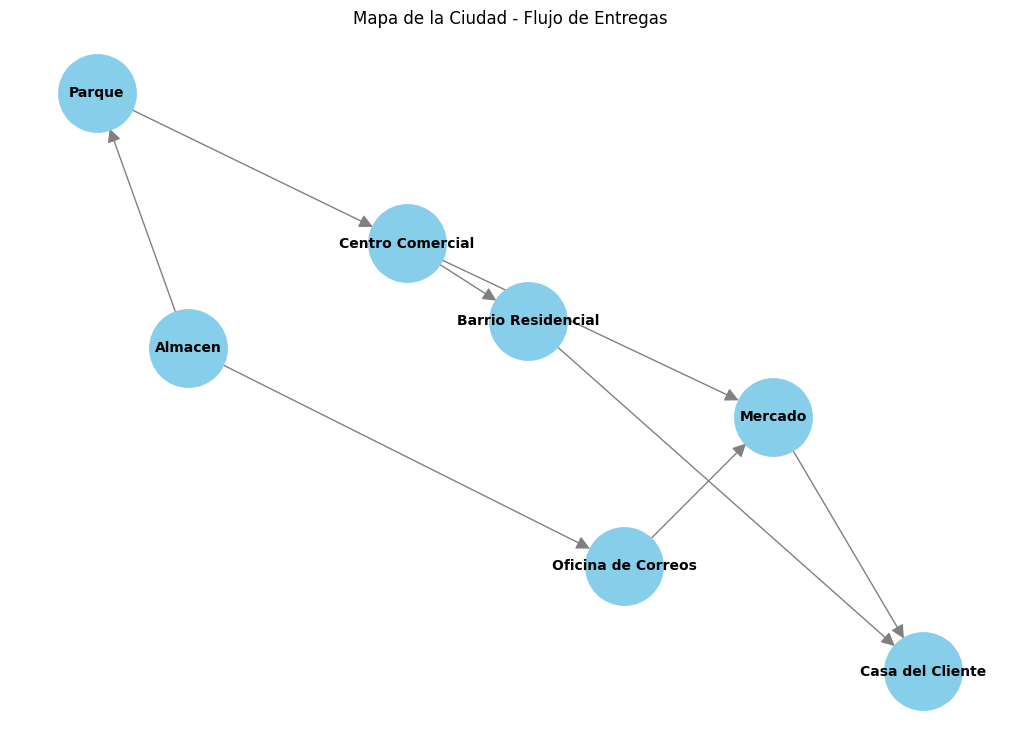

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Definir el grafo (tu diccionario)
mapa_ciudad = {
    'Almacen': ['Parque', 'Oficina de Correos'],
    'Parque': ['Centro Comercial'],
    'Oficina de Correos': ['Mercado'],
    'Centro Comercial': ['Mercado', 'Barrio Residencial'],
    'Mercado': ['Casa del Cliente'],
    'Barrio Residencial': ['Casa del Cliente'],
    'Casa del Cliente': []
}

# 2. Crear un objeto de grafo dirigido con NetworkX
G = nx.DiGraph()

# 3. Añadir las conexiones al grafo
for nodo, vecinos in mapa_ciudad.items():
    for vecino in vecinos:
        G.add_edge(nodo, vecino)

# 4. Configurar el diseño (layout) y el dibujo
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)  # Posicionamiento de los nodos

# Dibujar nodos, flechas y etiquetas
nx.draw(G, pos, with_labels=True, 
        node_color='skyblue', 
        node_size=3000, 
        edge_color='gray', 
        linewidths=2, 
        font_size=10, 
        font_weight='bold', 
        arrowsize=20)

plt.title("Mapa de la Ciudad - Flujo de Entregas")
plt.show()

## Tu Misión: ¡A Programar!

In [16]:
from collections import deque

# --- 1. Definición del Mapa ---
mapa_ciudad = {
  'Almacen': ['Parque', 'Oficina de Correos'],
  'Parque': ['Centro Comercial'],
  'Oficina de Correos': ['Mercado'],
  'Centro Comercial': ['Mercado', 'Barrio Residencial'],
  'Mercado': ['Casa del Cliente'],
  'Barrio Residencial': ['Casa del Cliente'],
  'Casa del Cliente': []
}

# --- 2. Algoritmos de Búsqueda ---
def find_path_bfs(graph, start, goal):
    queue = deque([ [start] ])
    visited = set([start])
    
    while queue:
        path = queue.popleft()
        node = path[-1]
        
        if node == goal:
            return path
            
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
                
    return None

def find_path_dfs(graph, start, goal, path=None):
    if path is None:
        path = [start]
        
    if start == goal:
        return path
        
    for neighbor in graph[start]:
        if neighbor not in path:
            new_path = find_path_dfs(graph, neighbor, goal, path + [neighbor])
            if new_path:
                return new_path
                
    return None

# --- 3. Ejecución de la Misión ---
inicio = 'Almacen'
destino = 'Casa del Cliente'

print("🤖 Iniciando sistema de navegación del robot de entregas...\n")

🤖 Iniciando sistema de navegación del robot de entregas...



## Paso 3: Análisis Detallado de la Ejecución de BFS

In [17]:
ruta_bfs = find_path_bfs(mapa_ciudad, inicio, destino)
print(f"Ruta óptima encontrada (BFS): {ruta_bfs}")

Ruta óptima encontrada (BFS): ['Almacen', 'Oficina de Correos', 'Mercado', 'Casa del Cliente']


## Paso 4: Análisis Detallado de la Ejecución de DFS

In [18]:
ruta_dfs = find_path_dfs(mapa_ciudad, inicio, destino)
print(f"Ruta alternativa encontrada (DFS): {ruta_dfs}")

Ruta alternativa encontrada (DFS): ['Almacen', 'Parque', 'Centro Comercial', 'Mercado', 'Casa del Cliente']


### 1. ¿Qué ruta encontró BFS? ¿Cuántos pasos tiene?
- Ruta: ['Almacen', 'Oficina de Correos', 'Mercado', 'Casa del Cliente']

- Pasos: Tiene 3 saltos (o 4 nodos visitados). Al explorar por niveles, el algoritmo descubrió rápidamente que la Oficina de Correos ofrecía un atajo directo al Mercado.

### 2. ¿Qué ruta encontró DFS? ¿Es diferente a la de BFS?
- Ruta: ['Almacen', 'Parque', 'Centro Comercial', 'Mercado', 'Casa del Cliente']

- Pasos: Tiene 4 saltos (o 5 nodos visitados). Sí, es completamente diferente y más larga que la de BFS.

### 3. ¿Por qué crees que encontraron rutas diferentes (o la misma ruta)?
- Ocurre por la estructura de datos que rige cada algoritmo. El DFS miró la primera opción en la lista del Almacén (Parque) y se "zambulló" por esa rama sin pensarlo dos veces: del Parque pasó al Centro Comercial, y del Centro Comercial al Mercado, llegando a la meta sin darse cuenta de que existía un camino más rápido. El BFS, al usar una cola, fue metódico: revisó a qué distancia estaban el Parque y la Oficina de Correos simultáneamente antes de dar el siguiente paso.

### 4. Si el robot tuviera que hacer una parada en el 'Mercado' obligatoriamente, ¿cómo modificarías el problema?

La forma más eficiente y elegante de programar esto es dividir el problema en dos fases, encadenando las búsquedas:

1. Ejecutar find_path_bfs desde 'Almacen' hasta 'Mercado'.

2. Ejecutar find_path_bfs desde 'Mercado' hasta 'Casa del Cliente'.

3. Concatenar ambas listas resultantes (teniendo cuidado de no duplicar el nodo 'Mercado' en la lista final).